# 1. Import libraries and set up the environment

In [2]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
from plotly.offline import init_notebook_mode
import plotly.offline as py
import cufflinks as cf
import plotly.graph_objs as go

# Set up for Plotly
py.init_notebook_mode(connected=True)
cf.go_offline()

# Set up the display environment
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

# 2. Read and inspect the initial data

In [4]:
# Read data from a CSV file
df_initial=pd.read_csv('data.csv', encoding='ISO-8859-1', dtype={'CustomerID': str, 'InvoiceNo': str})
print(f'DataFrame dimensions: {df_initial.shape}')

# Convert the date format
df_initial['InvoiceDate']=pd.to_datetime(df_initial['InvoiceDate'])

# Overview of information about the columns
def get_info_summary(df):
    return pd.DataFrame({
        'Column Type': df.dtypes,
        'Null Values (Count)': df.isnull().sum(),
        'Null Values (%)': df.isnull().sum()/df.shape[0]*100
    })
info_summary=get_info_summary(df_initial)
info_summary

DataFrame dimensions: (541909, 8)


,Column Type,Null Values (Count),Null Values (%)
InvoiceNo,object,0,0.000000
StockCode,object,0,0.000000
Description,object,1454,0.268311
Quantity,int64,0,0.000000
InvoiceDate,datetime64[ns],0,0.000000
UnitPrice,float64,0,0.000000
CustomerID,object,135080,24.926694
Country,object,0,0.000000


# 3. Data preprocessing

In [6]:
# Display the first 5 rows of the data
df_initial.head()

# Remove rows where CustomerID is null
df_initial.dropna(subset=['CustomerID'], inplace=True)
print(f'DataFrame dimensions after dropping nulls: {df_initial.shape}')

# Check and delete duplicate rows
print(f'Duplicated entries: {df_initial.duplicated().sum()}')
df_initial.drop_duplicates(inplace=True)

# Information about the columns after processing
info_summary=get_info_summary(df_initial)
info_summary

DataFrame dimensions after dropping nulls: (406829, 8)
Duplicated entries: 5225


,Column Type,Null Values (Count),Null Values (%)
InvoiceNo,object,0,0.0
StockCode,object,0,0.0
Description,object,0,0.0
Quantity,int64,0,0.0
InvoiceDate,datetime64[ns],0,0.0
UnitPrice,float64,0,0.0
CustomerID,object,0,0.0
Country,object,0,0.0


# 4. Data analysis by country and Choropleth chart

Number of countries in the dataframe: 37


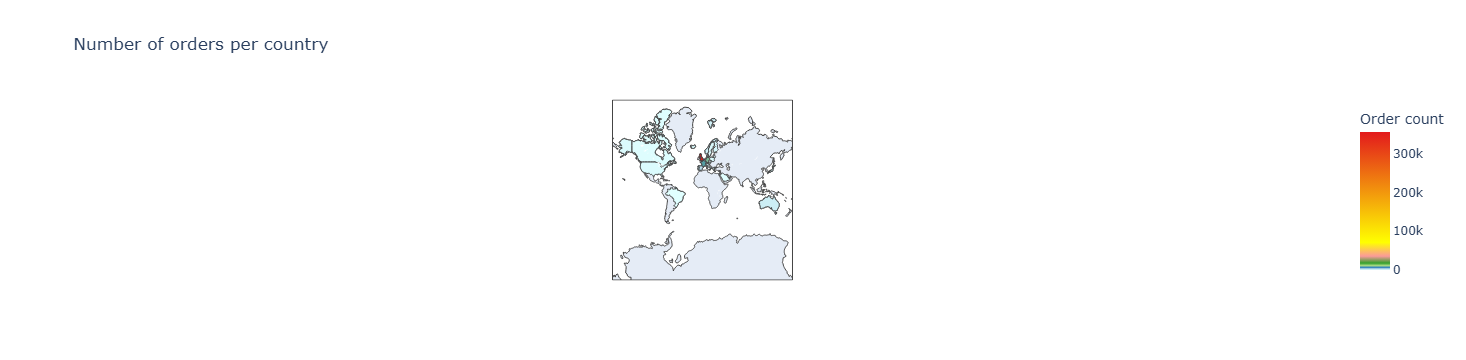

In [8]:
# Analysis of the number of orders by country
countries=df_initial['Country'].value_counts()
print(f'Number of countries in the dataframe: {len(countries)}')

# Create a Choropleth chart
data=dict(
    type='choropleth',
    locations=countries.index,
    locationmode='country names',
    z=countries.values,
    text=countries.index,
    colorbar={'title':'Order count'},
    colorscale=[
        [0, 'rgb(224,255,255)'],
        [0.01, 'rgb(166,206,227)'],
        [0.02, 'rgb(31,120,180)'],
        [0.03, 'rgb(178,223,138)'],
        [0.05, 'rgb(51,160,44)'],
        [0.10, 'rgb(251,154,153)'],
        [0.20, 'rgb(255,255,0)'],
        [1, 'rgb(227,26,28)']
    ],
    reversescale=False
)
layout=dict(title='Number of orders per country', geo=dict(showframe=True, projection={'type':'mercator'}))
choromap=go.Figure(data=[data], layout=layout)
py.iplot(choromap, validate=False)

# 5. Data statistics

In [10]:
# Statistics of the number of products, transactions, and customers
stats_summary=pd.DataFrame({
    'Product': [len(df_initial['StockCode'].value_counts())],
    'Transactions':[len(df_initial['InvoiceNo'].value_counts())],
    'Customers': [len(df_initial['CustomerID'].value_counts())]
})
stats_summary

,Product,Transactions,Customers
0,3684,22190,4372


# 6. Analyze shopping carts and handle canceled orders

In [12]:
# Analyze shopping carts
basket_summary=df_initial.groupby(['CustomerID','InvoiceNo'], as_index=False)['InvoiceDate'].count()
basket_summary.rename(columns={'InvoiceDate':'Number of Products'}, inplace=True)

# Identify canceled orders
basket_summary['Order Canceled']=basket_summary['InvoiceNo'].apply(lambda x: int('C' in x))
canceled_count=basket_summary['Order Canceled'].sum()
total_orders=basket_summary.shape[0]
print(f'Number of canceled orders: {canceled_count}/{total_orders} ({canceled_count/total_orders:.2f}%)')

Number of canceled orders: 3654/22190 (0.16%)


# 7. Check orders and related items

In [14]:
# Check orders and related items
df_check=df_initial[df_initial['Quantity']<0][['CustomerID','Quantity','StockCode','Description','UnitPrice']]
for index, col in df_check.iterrows():
    if df_initial[(df_initial['CustomerID']==col[0])&(df_initial['Quantity']==-col[1])&(df_initial['StockCode']==col[2])].shape[0]==0:
        print(df_check.loc[index])
        print('Hypothesis not fulfilled')
        break

CustomerID        14527
Quantity             -1
StockCode             D
Description    Discount
UnitPrice          27.5
Name: 141, dtype: object
Hypothesis not fulfilled


# 8. Process cleaner data

In [16]:
# Process cleaner data
df_cleaned = df_initial.copy()
df_cleaned['QuantityCanceled'] = 0
entry_to_remove = []
doubtful_entry = []

for index, col in df_initial.iterrows():
    # Ignore products with a positive quantity or those labeled as 'Discount'
    if col['Quantity'] > 0 or col['Description'] == 'Discount':
        continue

    # Find all previous orders with a positive quantity that have the same CustomerID and StockCode
    df_test = df_initial[(df_initial['CustomerID'] == col['CustomerID']) &
                         (df_initial['StockCode'] == col['StockCode']) &
                         (df_initial['InvoiceDate'] < col['InvoiceDate']) &
                         (df_initial['Quantity'] > 0)]
    
    if df_test.shape[0] == 0:
        # If no valid orders are found, mark it as a suspicious item
        doubtful_entry.append(index)
    else:
        # If one or more valid orders are found, process them
        total_cancellation = -col['Quantity']  # Cancellation quantity for the current order

        for ind, val in df_test.iterrows():
            if total_cancellation <= 0:
                break  # If there is no quantity left to cancel, stop
            if val['Quantity'] > 0:
                # Update only if the quantity of the current order is sufficient to offset the cancellation quantity
                if val['Quantity'] >= total_cancellation:
                    df_cleaned.loc[ind, 'QuantityCanceled'] += total_cancellation
                    total_cancellation = 0  # Cancel the quantity
                    entry_to_remove.append(index)  # Mark the order as canceled
                else:
                    # If insufficient, cancel the entire quantity in the order
                    df_cleaned.loc[ind, 'QuantityCanceled'] += val['Quantity']
                    total_cancellation -= val['Quantity']  # Update the remaining quantity
                    entry_to_remove.append(index)  # Mark the order as canceled

print(f"Entries to remove: {len(entry_to_remove)}")
print(f"Doubtful entries: {len(doubtful_entry)}")

# Remove invalid items
df_cleaned.drop(entry_to_remove + doubtful_entry, axis=0, inplace=True)


Entries to remove: 8010
Doubtful entries: 1226


# 9. Calculate the total cart value and analyze the price range

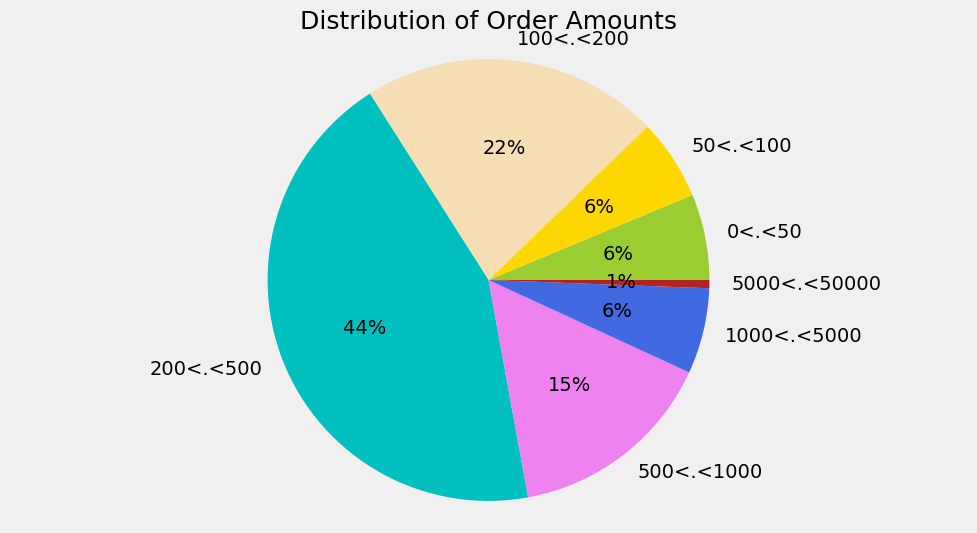

In [18]:
# Calculate the total cart value
df_cleaned['TotalPrice']=df_cleaned['UnitPrice']*(df_cleaned['Quantity']-df_cleaned['QuantityCanceled'])
df_cleaned.sort_values('CustomerID', inplace=True)

# Analyze the price range
basket_price=df_cleaned.groupby(['CustomerID', 'InvoiceNo'], as_index=False)['TotalPrice'].sum()
basket_price=basket_price[basket_price['TotalPrice']>0]
price_range=[0, 50, 100, 200, 500, 1000, 5000, 50000]
count_price=[basket_price[(basket_price['TotalPrice']<price) &
                          (basket_price['TotalPrice']>price_range[i-1])].shape[0]
             for i, price in enumerate(price_range) if i != 0]

# Draw a pie chart
plt.figure(figsize=(11,6))
colors=['yellowgreen', 'gold', 'wheat', 'c', 'violet', 'royalblue', 'firebrick']
labels=[f'{price_range[i-1]}<.<{price}' for i, price in enumerate(price_range) if i != 0]
plt.pie(count_price, labels=labels, colors=colors, autopct='%1.0f%%', shadow=False, startangle=0)
plt.axis('equal')
plt.title('Distribution of Order Amounts', fontsize=18)
plt.show()

In [ ]:
df_cleaned.to_csv('cleaned_data.csv', index=False)